In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from namespaces import DA

In [2]:
os.chdir('/home/mai/notebooks/final_thesis/')
os.getcwd()

'/home/mai/notebooks/final_thesis'

# 1. Load data

In [3]:

data = np.load(os.path.join(DA.paths.output_data_ml, 'dgraphfin_processed.npz'))

In [4]:
X_train = pd.DataFrame(data['x_train'])
y_train = pd.DataFrame(data['y_train'])

X_train.columns = [f'var_{col}' for col in X_train.columns]
y_train.columns = ['y']

In [5]:
X_train.shape, y_train.shape

((857899, 17), (857899, 1))

# 2. Check class imbalance

In [6]:
# check class ratio
y_train['y'].value_counts(normalize=True)

y
0    0.987345
1    0.012655
Name: proportion, dtype: float64

# 3. Check missing values

In [7]:
# check missing ratio (encoded as -1)
(X_train == -1).mean()

var_0     0.002067
var_1     0.002068
var_2     0.355665
var_3     0.356076
var_4     0.356076
var_5     0.388422
var_6     0.355665
var_7     0.388422
var_8     0.356076
var_9     0.356076
var_10    0.000000
var_11    0.395956
var_12    0.395956
var_13    0.388423
var_14    0.410867
var_15    0.561573
var_16    0.561573
dtype: float64

# 4. Check variable summaries

In [8]:
# replace -1 with actual np.nan
X_train_with_nan = X_train.replace(-1, np.nan)

X_train_with_nan.describe().T

# for col in X_train.columns:
#     unique_values = X_train[X_train[col] != -1][col].nunique()
#     var_summary = X_train[X_train[col] != -1][col].describe()
#     print(f"Variable {col}: {unique_values} unique values")
#     print(var_summary)
#     print()

,count,mean,std,min,25%,50%,75%,max
var_0,856126.0,0.750488,0.432731,0.000000,1.000000,1.000000,1.000000,1.000
var_1,856125.0,3.718811,1.924961,0.000000,2.000000,4.000000,5.000000,8.000
var_2,552774.0,1.398388,1.950361,0.005000,0.405000,0.855000,1.695000,111.815
var_3,552422.0,1.161307,1.784286,0.005000,0.325000,0.685000,1.360000,111.475
var_4,552422.0,0.824853,0.131918,0.028446,0.752294,0.850746,0.923345,1.000
var_5,524672.0,1.150758,1.856759,0.100000,0.400000,0.700000,1.400000,456.300
var_6,552774.0,2.044119,2.930094,0.001000,0.359000,1.019000,2.490000,64.119
var_7,524672.0,0.234248,0.449797,0.001000,0.018000,0.073000,0.248000,12.338
var_8,552422.0,1.975132,2.873278,0.001000,0.332000,0.963000,2.399000,63.416
var_9,552422.0,0.943225,0.075178,0.002558,0.930000,0.968116,0.986633,1.000


# 5. Separate numeric and categorical variables

In [9]:
CAT_VARS = [col for col in X_train.columns if X_train[X_train[col] != -1][col].nunique() < 10]
NUM_VARS = [col for col in X_train.columns if col not in CAT_VARS]

print(f"Number of categorical variables: {len(CAT_VARS)}")
print(f"Number of numeric variables: {len(NUM_VARS)}")

Number of categorical variables: 2
Number of numeric variables: 15


# 6. Plot variable distribution

In [10]:
df_train = pd.concat([X_train, y_train], axis=1)
df_train = df_train.replace(-1, np.nan)

df_train.head()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,y
0,1.0,5.0,0.375,0.30,0.800000,0.5,0.321,0.021,0.305,0.950156,2.0,0.200000,0.049844,0.083333,0.800000,0.026667,0.400000,1
1,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1.0,6.0,1.020,0.93,0.911765,0.6,1.356,0.103,1.327,0.978614,1.0,0.088235,0.021386,0.032258,0.833333,0.004902,0.166667,1
3,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1


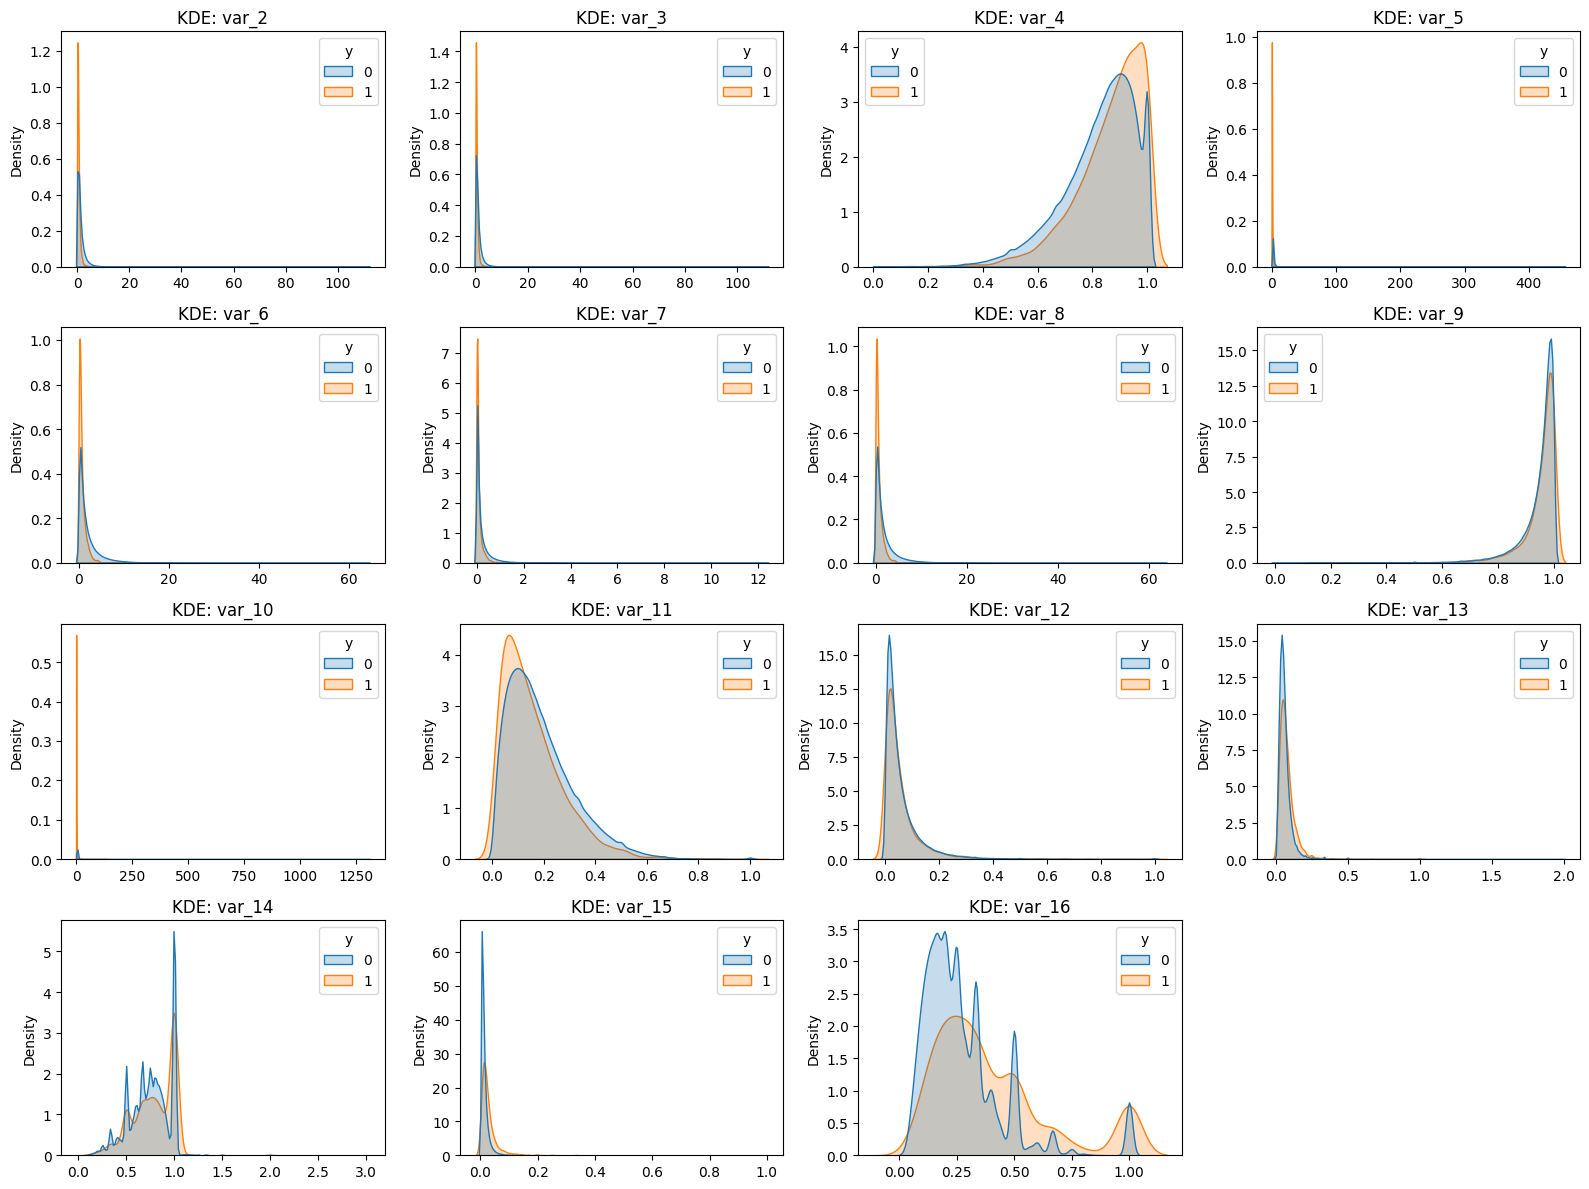

In [11]:
import math 

# Identify feature columns (excluding the target)
n_features = len(NUM_VARS)

# Define grid dimensions (e.g., 4 columns wide)
cols = 4
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, col in enumerate(NUM_VARS):
    # Plot KDE for each feature, split by target class
    sns.kdeplot(data=df_train[[col, 'y']].dropna(), x=col, hue='y', ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(f'KDE: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# Hide any empty subplots in the grid
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

In [12]:
for col in CAT_VARS:
    print(f"--- Distribution of Target=1 for: {col} ---")
    # Calculate the mean (proportion of 1s) and the count for context
    dist = df_train.groupby(col)['y'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
    dist['percentage'] = (dist['mean'] * 100).round(2).astype(str) + '%'
    print(dist[['percentage', 'count']])
    print("\n")

--- Distribution of Target=1 for: var_0 ---
      percentage   count
var_0                   
1.0        1.33%  642512
0.0        1.08%  213614


--- Distribution of Target=1 for: var_1 ---
      percentage   count
var_1                   
8.0        1.91%   35532
0.0        1.56%   30255
7.0        1.47%   41545
6.0        1.36%   68700
5.0         1.3%  142543
4.0        1.25%  152179
2.0        1.15%  113366
3.0        1.15%  188164
1.0        1.13%   83841


